
<div dir=ltr align=center>

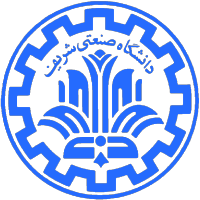

<br>
<font>
<div dir=ltr align=center>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Artificial Intelligence <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Arash Marioriyad<br>
    Spring 2026<br>
<font color=3C99D size=5>
    Practical HomeWork 4<br>
    ML CORE<br>
<font color=696880 size=4>
    Ilya Forsati

____

Name: `Your Name`

SID: `YOUR SID`

> **Implementation Note:** Every model in this notebook — `LinearRegressionScratch`, `PerceptronScratch`, `LogisticRegressionScratch`, and `NeuralNetworkScratch` — is implemented **from scratch using only `numpy`**. No pre-built estimators from `scikit-learn` are used for learning. Utility tools like `PolynomialFeatures` (for feature engineering) and the dataset generators (`make_blobs`, `make_circles`, etc.) are still used for data preparation.

# From Linear Models to Neural Networks

## Concepts

In this notebook, we will journey from basic linear models to deep learning. All models are implemented **from scratch using only `numpy`**, giving us a direct look at the internal mechanics — from gradient descent to backpropagation.

- **Linear Regression**
  - Linear Regression for continuous variables
  - Linear Regression for classification
  - Limitations of Linear Regression in classification tasks

- **Perceptron**
  - Binary classification
  - Linear decision boundaries
  - Perceptron learning algorithm
  - Failure on non-linearly separable data (XOR/Circles)

- **Logistic Regression & Feature Engineering**
  - Sigmoid function
  - Probabilistic classification
  - Logistic Regression on linear datasets
  - Failure on nonlinear datasets
  - Feature engineering (Polynomial features)

- **Neural Networks**
  - Hidden layers
  - Nonlinear activation functions
  - Forward propagation
  - Backpropagation
  - Automatic feature learning on complex data (Spiral)

## 0. Datasets

In this notebook, we will use several synthetic datasets to study the behavior of different machine learning models, followed by a real-world dataset. Each dataset is designed to demonstrate a specific concept or limitation.

### Datasets Used

- `make_regression` (Linear)
  - Linear regression on continuous targets
  
- **Non-linear Regression**
  - A quadratic dataset to demonstrate the need for Feature Engineering (Polynomial Features)

- **1D Classification (with outliers)**
  - Used to show why Linear Regression (MSE) fails for classification

- `make_blobs` (Linearly Separable)
  - Linearly separable classification dataset
  - Used to demonstrate the success of Perceptron and Logistic Regression
  
- `make_blobs` (Non-linearly Separable)
  - Used to show overlapping classes and soft margins

- `make_circles`
  - Nonlinear classification dataset
  - Used to show the need for manual Feature Engineering in classification

- **Spiral dataset (4 classes)**
  - Complex nonlinear dataset
  - Used to demonstrate the power of Neural Networks (which we will build from scratch)

- **The Checkerboard Dataset**
  - Grid XOR logic
  - The ultimate test where even advanced Feature Engineering fails

- **MNIST (Real-World)**
  - Handwritten digits (0-9)
  - Used to test our models on high-dimensional data (784 features)

We load and visualize all datasets below. Each later experiment references one of these sets to show where a model works and where it breaks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_regression,
    make_blobs,
    make_circles
)

# 1. Linear Regression Dataset
X_reg, y_reg = make_regression(
    n_samples=200, n_features=1, noise=15, random_state=42
)

# 2. Non-linear Regression Dataset (For Feature Engineering)
np.random.seed(42)
X_nonlin = np.sort(np.random.rand(100, 1) * 10 - 5, axis=0)
y_nonlin = 0.5 * (X_nonlin[:, 0] ** 2) + X_nonlin[:, 0] - 2 + np.random.randn(100) * 2

# 3. 1D Classification Dataset with Outlier
np.random.seed(42)
n_samples_1d = 50
X_class_1d = np.random.randn(n_samples_1d, 1) * 2
y_class_1d = (X_class_1d.flatten() > 0).astype(int)

outlier_indices = [44, 45, 46, 47]
X_class_1d[outlier_indices] = np.array([[8], [10], [9], [11]])
y_class_1d[outlier_indices] = [1, 1, 1, 1]

# 4. Linearly Separable Blobs
X_separable, y_separable = make_blobs(
    n_samples=300, n_features=2, centers=[[-4, 0], [4, 0]], cluster_std=[1, 2], random_state=42
)

# 5. Non-linearly Separable Blobs
X_nonseparable, y_nonseparable = make_blobs(
    n_samples=300, n_features=2, centers=[[-4, 0], [4, 0]], cluster_std=[2.5, 2.5], random_state=42
)

# 6. Circles
X_circles, y_circles = make_circles(
    n_samples=500, noise=0.1, factor=0.5, random_state=42
)

# 7. Spiral Dataset (4 Classes)
def generate_spiral_dataset_4classes(points_per_class=250, noise=0.2, n_classes=4):
    X = np.zeros((points_per_class * n_classes, 2))
    y = np.zeros(points_per_class * n_classes, dtype=int)
    
    for j in range(n_classes):
        ix = range(points_per_class * j, points_per_class * (j + 1))
        r = np.linspace(0.15, 1.0, points_per_class)
        
        theta_start = j * (2 * np.pi / n_classes)
        theta_end = theta_start + 4.5
        t = np.linspace(theta_start, theta_end, points_per_class)
        
        t += np.random.randn(points_per_class) * noise
        
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
        
    return X, y

X_spiral4, y_spiral4 = generate_spiral_dataset_4classes()

# 8. The Checkerboard Dataset 
def generate_checkerboard(n_samples=800, grid_size=4, noise=0.1):
    X = np.random.rand(n_samples, 2) * grid_size
    x_cell = np.floor(X[:, 0])
    y_cell = np.floor(X[:, 1])
    y = (x_cell % 2) == (y_cell % 2)
    y = y.astype(int)
    X += np.random.randn(*X.shape) * noise
    return X, y

X_checker, y_checker = generate_checkerboard(n_samples=800, grid_size=4, noise=0.1)

# 9. MNIST Dataset (Local File Loading)
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        # Skip the first 16 bytes (magic number and dimensions)
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28 * 28) / 255.0

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        # Skip the first 8 bytes (magic number and item count)
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

print("Loading Local MNIST files from 'archive' directory...")
try:
    X_train = load_mnist_images('archive/train-images.idx3-ubyte')
    y_train = load_mnist_labels('archive/train-labels.idx1-ubyte')
    
    X_test = load_mnist_images('archive/t10k-images.idx3-ubyte')
    y_test = load_mnist_labels('archive/t10k-labels.idx1-ubyte')
    
    print("Data loading complete!")
except FileNotFoundError as e:
    print(f"ERROR: File not found! Details: {e}")

Loading Local MNIST files from 'archive' directory...
Data loading complete!


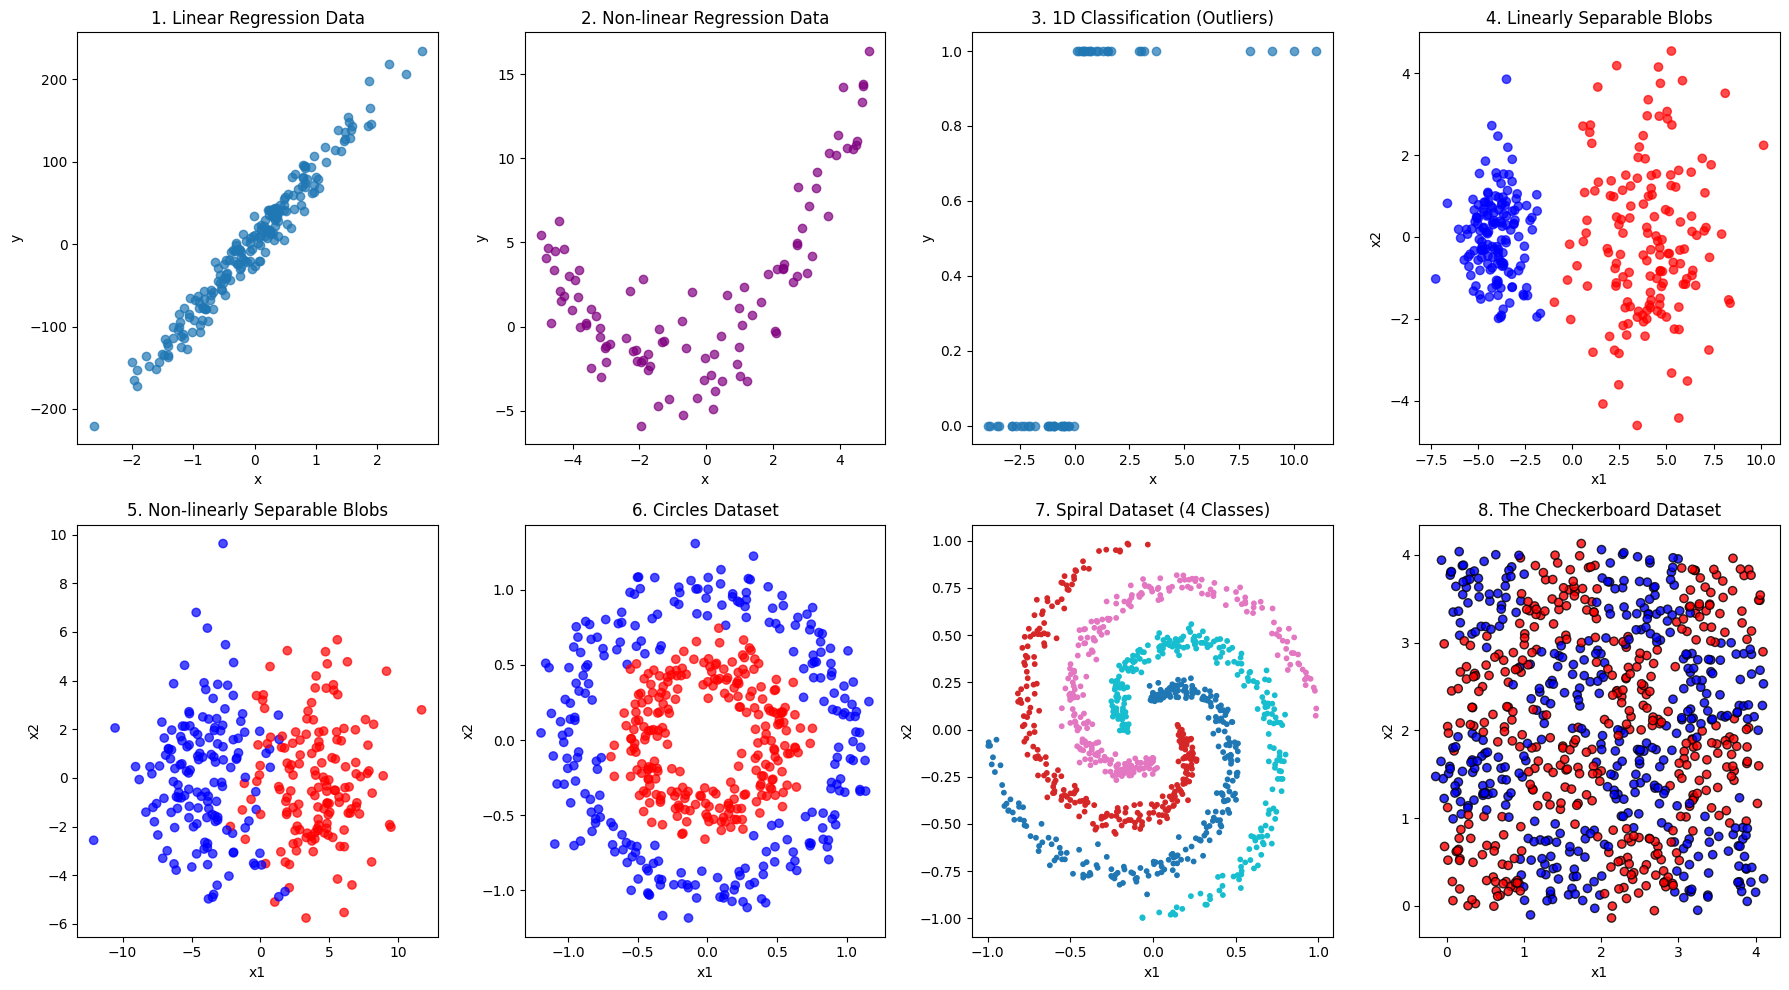

X shape: (60000, 784)
y shape: (60000,)


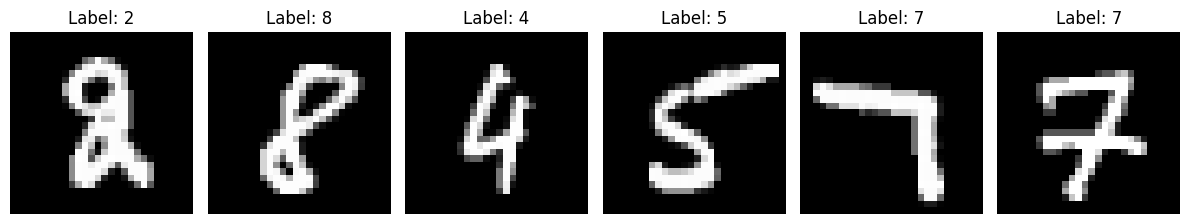

In [2]:
# Visualization of 2D Datasets (2x4 Grid)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# 1. Linear Regression
axes[0, 0].scatter(X_reg, y_reg, alpha=0.7)
axes[0, 0].set_title("1. Linear Regression Data")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

# 2. Non-linear Regression
axes[0, 1].scatter(X_nonlin, y_nonlin, alpha=0.7, color='purple')
axes[0, 1].set_title("2. Non-linear Regression Data")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")

# 3. 1D Classification
axes[0, 2].scatter(X_class_1d, y_class_1d, alpha=0.7)
axes[0, 2].set_title("3. 1D Classification (Outliers)")
axes[0, 2].set_xlabel("x")
axes[0, 2].set_ylabel("y")

# 4. Separable Blobs
axes[0, 3].scatter(X_separable[:, 0], X_separable[:, 1], c=y_separable, cmap="bwr", alpha=0.7)
axes[0, 3].set_title("4. Linearly Separable Blobs")
axes[0, 3].set_xlabel("x1")
axes[0, 3].set_ylabel("x2")

# 5. Non-separable Blobs
axes[1, 0].scatter(X_nonseparable[:, 0], X_nonseparable[:, 1], c=y_nonseparable, cmap="bwr", alpha=0.7)
axes[1, 0].set_title("5. Non-linearly Separable Blobs")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")

# 6. Circles
axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="bwr", alpha=0.7)
axes[1, 1].set_title("6. Circles Dataset")
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("x2")

# 7. Spiral (4 Classes)
axes[1, 2].scatter(X_spiral4[:, 0], X_spiral4[:, 1], c=y_spiral4, cmap="tab10", s=10)
axes[1, 2].set_title("7. Spiral Dataset (4 Classes)")
axes[1, 2].set_xlabel("x1")
axes[1, 2].set_ylabel("x2")

# 8. The Checkerboard Dataset 
axes[1, 3].scatter(X_checker[:, 0], X_checker[:, 1], c=y_checker, cmap="bwr", edgecolors="k", alpha=0.8)
axes[1, 3].set_title("8. The Checkerboard Dataset")
axes[1, 3].set_xlabel("x1")
axes[1, 3].set_ylabel("x2")

plt.tight_layout()
plt.show()

# Visualization of MNIST Dataset (1x6 Grid)
print("X shape:", X_train.shape) # (60000, 784)
print("y shape:", y_train.shape) # (60000,)

fig_m, axes_m = plt.subplots(1, 6, figsize=(12, 3))
indices = np.random.choice(len(X_train), 6, replace=False)

for i, ax in enumerate(axes_m):
    idx = indices[i]
    # reshape the 784 flat array back to 28x28 for plotting
    img = X_train[idx].reshape(28, 28)
    
    ax.imshow(img, cmap="gray")
    ax.set_title("Label: " + str(y_train[idx]))
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1. Linear Regression

Linear Regression models the relationship between inputs and a target as a linear function: $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$. 

- Linear Regression
  - Linear Regression for continuous variables
  - Linear Regression for classification
  - Limitations of Linear Regression in classification tasks

### The Implementation: From Scratch with NumPy

#### Core Math

Given input $\mathbf{X} \in \mathbb{R}^{n \times p}$, weights $\mathbf{w} \in \mathbb{R}^p$, and bias $b$:

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

**Loss — Mean Squared Error:**

$$J(\mathbf{w}, b) = \frac{1}{n} \|\hat{\mathbf{y}} - \mathbf{y}\|^2$$

**Gradients:**

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{2}{n} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y}), \quad \frac{\partial J}{\partial b} = \frac{2}{n} \sum_i (\hat{y}_i - y_i)$$

**Gradient Descent Update (repeated for `epochs` steps):**

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial J}{\partial \mathbf{w}}, \quad b \leftarrow b - \eta \frac{\partial J}{\partial b}$$

#### Implementation Details

Two practical enhancements make training stable across datasets with different scales:

1. **Feature Standardization:** The input is normalized to zero mean and unit variance before training. This prevents features with large magnitudes from dominating the gradient.
2. **`coef_` / `intercept_` properties:** After training in the normalized space, the learned weights and bias are mapped back to the original feature space for easy inspection.

In [ ]:
import numpy as np

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, epochs=5000, normalize=True):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.normalize = normalize
        self._w = None
        self._b = None
        self._x_mean = None
        self._x_std = None

    def fit(self, X, y):
        # TODO

        return self

    @property
    def coef_(self):
        if self.normalize:
            return self._w / self._x_std
        return self._w.copy()

    @property
    def intercept_(self):
        if self.normalize:
            return float(self._b - np.dot(self._w / self._x_std, self._x_mean))
        return float(self._b)

    def predict(self, X):
        if self.normalize:
            X = (X - self._x_mean) / self._x_std
        # TODO
        pass

### Simple Linear Regression
Let's start with a standard regression problem.
We will use `LinearRegressionScratch` to fit a line to our continuous dataset (`X_reg`, `y_reg`).

The model follows the familiar convention:
1. Initialize the model.
2. `fit(X, y)` — trains via gradient descent.
3. `predict(X)` — returns predictions.

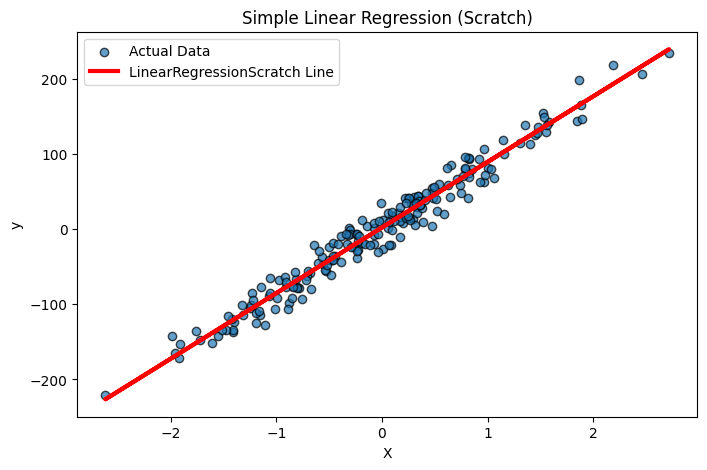

Learned Coefficient (Weight): 87.1810
Learned Intercept (Bias): 2.1428


In [4]:
# Simple Linear Regression (Scratch)
lr_scratch = LinearRegressionScratch(learning_rate=0.1, epochs=5000)
lr_scratch.fit(X_reg, y_reg)
y_pred_scratch = lr_scratch.predict(X_reg)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, alpha=0.7, edgecolors='k', label="Actual Data")
plt.plot(X_reg, y_pred_scratch, color="red", linewidth=3, label="LinearRegressionScratch Line")
plt.title("Simple Linear Regression (Scratch)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Learned Coefficient (Weight): {lr_scratch.coef_[0]:.4f}")
print(f"Learned Intercept (Bias): {lr_scratch.intercept_:.4f}")

### When Linear Regression Fails: Feature Engineering
What happens if the relationship between $X$ and $y$ is **not** a straight line? 
Let's generate a new non-linear dataset (a quadratic curve) and see how a simple straight line fails. 

Then, we will use **Polynomial Features** to transform our input data ($X \rightarrow X, X^2$). This allows our linear model to fit a curve!

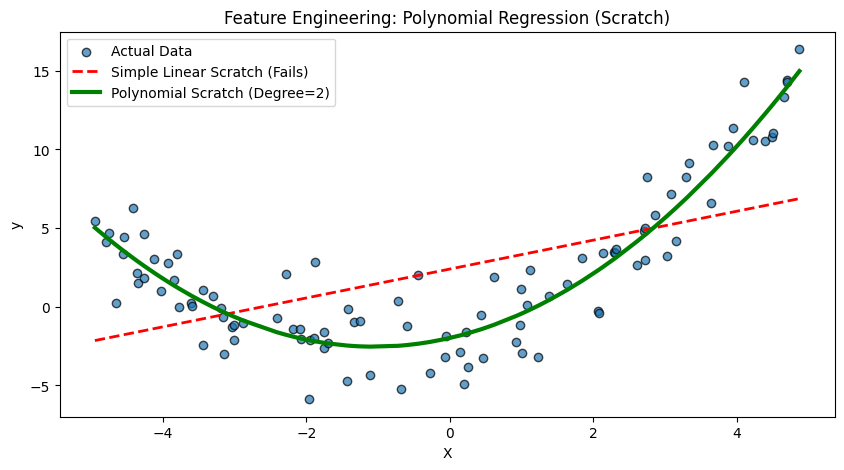

In [5]:
# Non-linear Regression with Feature Engineering (Scratch)
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_nonlin_poly = poly.fit_transform(X_nonlin)

lr_simple_scratch = LinearRegressionScratch(learning_rate=0.05, epochs=5000)
lr_simple_scratch.fit(X_nonlin, y_nonlin)
y_pred_simple_scratch = lr_simple_scratch.predict(X_nonlin)

lr_poly_scratch = LinearRegressionScratch(learning_rate=0.1, epochs=5000)
lr_poly_scratch.fit(X_nonlin_poly, y_nonlin)
y_pred_poly_scratch = lr_poly_scratch.predict(X_nonlin_poly)

plt.figure(figsize=(10, 5))
plt.scatter(X_nonlin, y_nonlin, alpha=0.7, edgecolors='k', label="Actual Data")
plt.plot(X_nonlin, y_pred_simple_scratch, color="red", linestyle="--", linewidth=2, label="Simple Linear Scratch (Fails)")
plt.plot(X_nonlin, y_pred_poly_scratch, color="green", linewidth=3, label="Polynomial Scratch (Degree=2)")
plt.title("Feature Engineering: Polynomial Regression (Scratch)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Can we use Linear Regression for Classification?
Since Linear Regression works so well, can we just use it to separate classes? 
Let's try to fit a line to our `1D Classification Dataset` and use a threshold (e.g., $y = 0.5$) to say:
- If prediction $\ge 0.5 \rightarrow$ Class 1
- If prediction $< 0.5 \rightarrow$ Class 0

Watch what happens when we have **outliers** in our data.

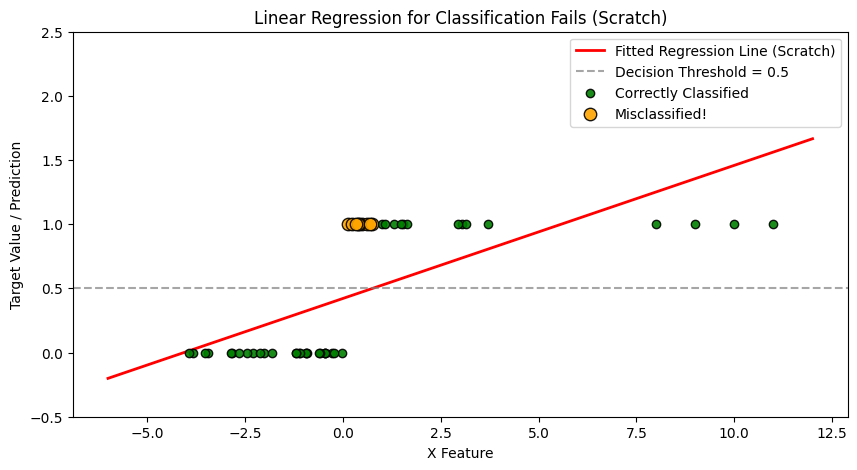

In [6]:
# Linear Regression for Classification (Scratch)
class_lr_scratch = LinearRegressionScratch(learning_rate=0.1, epochs=5000)
class_lr_scratch.fit(X_class_1d, y_class_1d)

X_plot = np.linspace(-6, 12, 300).reshape(-1, 1)
y_plot_scratch = class_lr_scratch.predict(X_plot)

y_pred_class_scratch = (class_lr_scratch.predict(X_class_1d) >= 0.5).astype(int)
correct_scratch = (y_pred_class_scratch == y_class_1d)

plt.figure(figsize=(10, 5))
plt.plot(X_plot, y_plot_scratch, color="red", linewidth=2, label="Fitted Regression Line (Scratch)")
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Decision Threshold = 0.5")
plt.scatter(X_class_1d[correct_scratch], y_class_1d[correct_scratch], color="green", alpha=0.9, edgecolors='k', label="Correctly Classified", zorder=5)
plt.scatter(X_class_1d[~correct_scratch], y_class_1d[~correct_scratch], color="orange", alpha=0.9, edgecolors='k', label="Misclassified!", s=80, zorder=5)
plt.xlabel("X Feature")
plt.ylabel("Target Value / Prediction")
plt.title("Linear Regression for Classification Fails (Scratch)")
plt.legend()
plt.ylim(-0.5, 2.5)
plt.show()

### Why did Linear Regression fail here?

**Your Answer:**


## 2. Perceptron

The Perceptron is the simplest linear classifier. It computes a weighted sum and outputs 0 or 1 based on a threshold.

### How it works

For input $\mathbf{x}$, weights $\mathbf{w}$, and bias $b$:

$$\hat{y} = \begin{cases} 1 & \text{if } \mathbf{w}^\top \mathbf{x} + b \ge 0 \\ 0 & \text{otherwise} \end{cases}$$

### Learning rule

Convert labels to $\{-1, +1\}$. For each misclassified sample ($y_i \cdot (\mathbf{w}^\top \mathbf{x}_i + b) \le 0$), update:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \, \mathbf{x}_i, \quad b \leftarrow b + \eta \, y_i$$

> If the data is linearly separable, Perceptron converges to a perfect solution.

### The Implementation: From Scratch with NumPy

The key insight: **correctly classified points are ignored entirely** — only misclassified samples trigger a weight update. The update fires only when $y_i' \cdot (\mathbf{w}^\top \mathbf{x}_i + b) \le 0$, where $y_i' = 2y_i - 1 \in \{-1, +1\}$.

#### Implementation Details

- **Online (sample-by-sample) updates**: the dataset is shuffled each epoch and samples are visited one at a time, reflecting the Perceptron's true online learning nature rather than batch processing.
- **`coef_` has shape `(1, n_features)` and `intercept_` has shape `(1,)`**, following the same convention used by the other models in this notebook.

In [ ]:
class PerceptronScratch:
    def __init__(self, learning_rate=1.0, max_iter=1000, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        # TODO

        return self

    def predict(self, X):
        # TODO
        pass

err 1d (scratch): 0.0
err blobs (scratch): 0.0


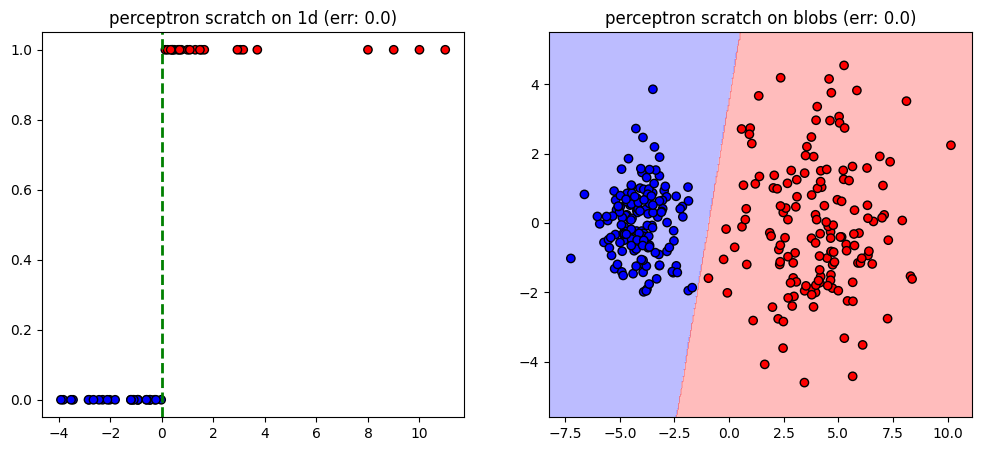

In [8]:
# Perceptron Scratch — success on separable data

p1_scratch = PerceptronScratch(learning_rate=1.0, max_iter=100)
p1_scratch.fit(X_class_1d, y_class_1d)
err1_scratch = np.mean(p1_scratch.predict(X_class_1d) != y_class_1d)
print("err 1d (scratch):", err1_scratch)

p2_scratch = PerceptronScratch(learning_rate=1.0, max_iter=1000)
p2_scratch.fit(X_separable, y_separable)
err2_scratch = np.mean(p2_scratch.predict(X_separable) != y_separable)
print("err blobs (scratch):", err2_scratch)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X_class_1d, y_class_1d, c=y_class_1d, cmap="bwr", edgecolors="k")
t_scratch = -p1_scratch.intercept_[0] / p1_scratch.coef_[0][0]
ax[0].axvline(t_scratch, color='green', linestyle='--', linewidth=2)
ax[0].set_title("perceptron scratch on 1d (err: " + str(err1_scratch) + ")")

x_min, x_max = X_separable[:, 0].min() - 1, X_separable[:, 0].max() + 1
y_min, y_max = X_separable[:, 1].min() - 1, X_separable[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
z = p2_scratch.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax[1].contourf(xx, yy, z, alpha=0.3, cmap="bwr")
ax[1].scatter(X_separable[:, 0], X_separable[:, 1], c=y_separable, cmap="bwr", edgecolors="k")
ax[1].set_title("perceptron scratch on blobs (err: " + str(err2_scratch) + ")")

plt.show()

### The Failure of Perceptron (Non-linearly Separable Data)

The Perceptron works perfectly when a single straight line can divide the classes. But what happens if the classes overlap or form complex shapes?

If the data is **not linearly separable** (like our `X_nonseparable` blobs or circles), the Perceptron learning rule will **never converge**. The weights will keep oscillating forever as the model gets confused by the overlapping points. With a fixed number of iterations, the resulting decision boundary is arbitrary and often poor.

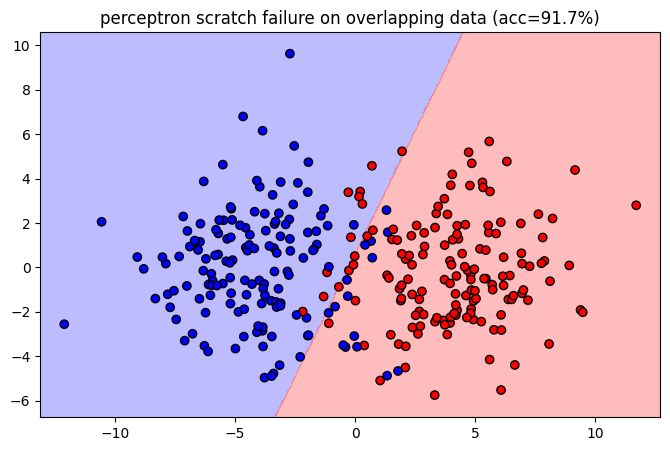

In [9]:
# Perceptron Scratch — failure on non-linearly separable data
p3_scratch = PerceptronScratch(learning_rate=1.0, max_iter=1000)
p3_scratch.fit(X_nonseparable, y_nonseparable)
err3_scratch = np.mean(p3_scratch.predict(X_nonseparable) != y_nonseparable)

x_min, x_max = X_nonseparable[:, 0].min() - 1, X_nonseparable[:, 0].max() + 1
y_min, y_max = X_nonseparable[:, 1].min() - 1, X_nonseparable[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
z = p3_scratch.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, z, alpha=0.3, cmap="bwr")
plt.scatter(X_nonseparable[:, 0], X_nonseparable[:, 1], c=y_nonseparable, cmap="bwr", edgecolors="k")
plt.title(f"perceptron scratch failure on overlapping data (acc={(1-err3_scratch)*100:.1f}%)")
plt.show()

## 3. Logistic Regression

Logistic Regression outputs **probabilities** instead of hard labels. It uses the sigmoid function to squash the linear score into $(0, 1)$.

### How it works

**Sigmoid function:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w}^\top \mathbf{x} + b$$

**Loss function — Binary Cross-Entropy:**

$$J(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \bigl[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \bigr]$$

**Gradient:**

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{n} \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y}), \quad \frac{\partial J}{\partial b} = \frac{1}{n} \sum (\hat{y}_i - y_i)$$

> Same form as Linear Regression, but $\hat{\mathbf{y}}$ passes through sigmoid.

### Key difference from Perceptron

| Perceptron | Logistic Regression |
|------------|---------------------|
| Hard 0/1 output | Probability $\in (0,1)$ |
| Updates only on mistakes | Updates every sample, scaled by error |
| No convergence guarantee for non-separable data | Always converges (to a probabilistic boundary) |

### The Implementation: From Scratch with NumPy

#### Implementation Details

- **Numerical stability**: the sigmoid clips its input to $[-500, 500]$ before calling `np.exp` to prevent overflow.
- **`predict_proba(X)`** returns per-class probabilities with shape `(n, 2)`.
- **`score(X, y)`** computes accuracy so the `plot_boundary` visualization helper below works unchanged.

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None

    @staticmethod
    def _sigmoid(z):
        # TODO
        pass

    def fit(self, X, y):
        # TODO
        return self

    def predict_proba(self, X):
        # TODO
        pass

    def predict(self, X):
        # TODO
        pass

    def score(self, X, y):
        # TODO
        pass

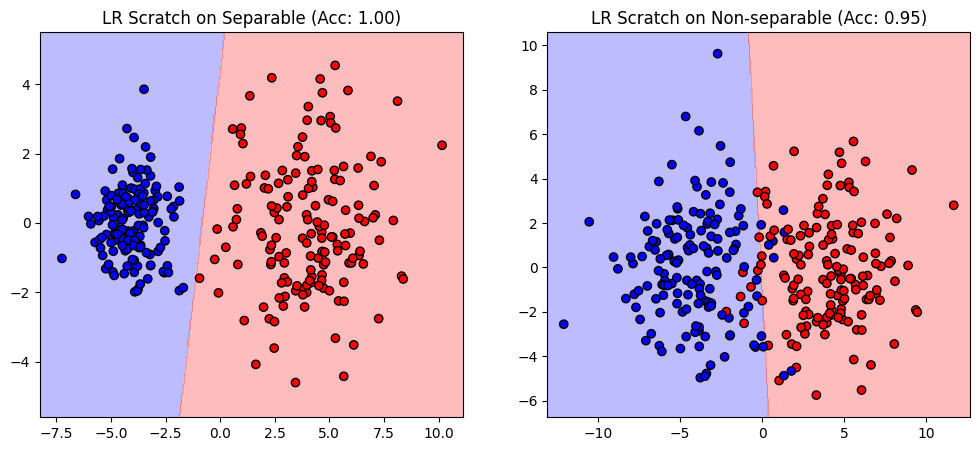

In [11]:
# Visualization helper used throughout this section
def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
    z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)
    ax.contourf(xx, yy, z, alpha=0.3, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    ax.set_title(title)

# Logistic Regression Scratch — Separable and Non-separable Blobs
lr_sep_scratch = LogisticRegressionScratch(learning_rate=0.5, max_iter=2000)
lr_sep_scratch.fit(X_separable, y_separable)
acc_sep_scratch = lr_sep_scratch.score(X_separable, y_separable)

lr_nonsep_scratch = LogisticRegressionScratch(learning_rate=0.5, max_iter=2000)
lr_nonsep_scratch.fit(X_nonseparable, y_nonseparable)
acc_nonsep_scratch = lr_nonsep_scratch.score(X_nonseparable, y_nonseparable)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(lr_sep_scratch, X_separable, y_separable, ax[0], f"LR Scratch on Separable (Acc: {acc_sep_scratch:.2f})")
plot_boundary(lr_nonsep_scratch, X_nonseparable, y_nonseparable, ax[1], f"LR Scratch on Non-separable (Acc: {acc_nonsep_scratch:.2f})")
plt.show()

### The Limits of Linearity: Circles, Spirals, and Checkerboards

Logistic Regression gracefully handles overlapping data by giving probabilities. However, its basic decision boundary is still just a **straight line**. 

If we apply it to a non-linear dataset like `Circles`, it will fail. We can temporarily fix this using **Feature Engineering** (e.g., adding polynomial features like $x_1^2$ and $x_2^2$ to bend the line into a circle). 

But what happens when the pattern is highly complex, like our **4-Class Spiral** or the highly repetitive **Checkerboard (Grid XOR)**? 

For these extremely non-linear datasets, manual feature engineering becomes a nightmare. We would need impractically high polynomial degrees to even attempt to separate them, which leads to massive computational costs, severe overfitting, and mathematical instability (the solver fails to converge). Let's observe how Logistic Regression completely breaks down on these tough datasets.

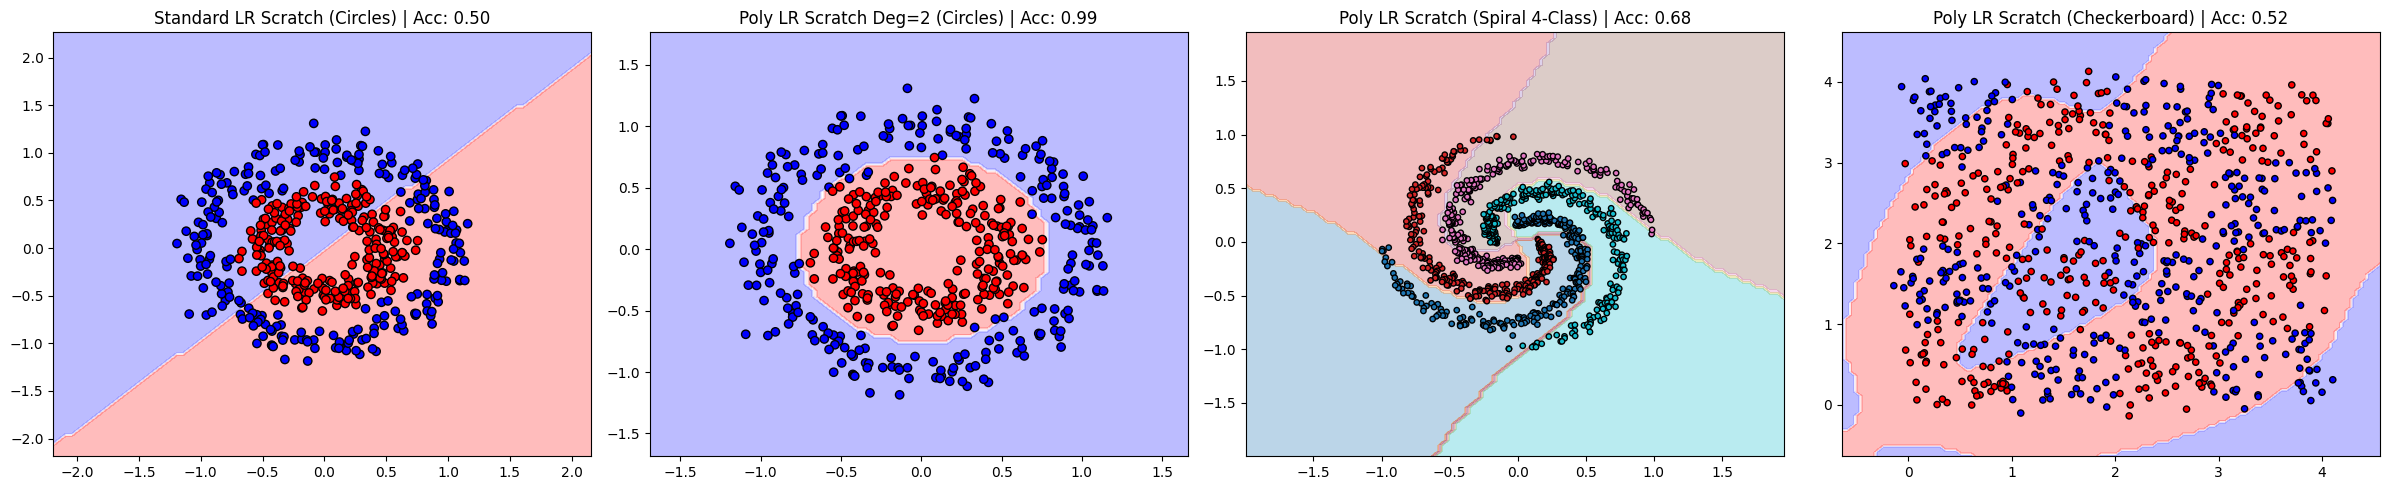

In [ ]:
# Logistic Regression Scratch — Limits on Non-linear Data (all 4 datasets)
from sklearn.preprocessing import PolynomialFeatures

# One-vs-Rest wrapper to extend LogisticRegressionScratch to multi-class problems
class OvRLogisticRegressionScratch:
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self._classifiers = []
        self._classes = None

    def fit(self, X, y):
        # TODO
        return self

    def predict(self, X):
        # TODO
        pass

    def score(self, X, y):
        # TODO
        pass

# 1. basic LR scratch on circles
lr_c_scratch = LogisticRegressionScratch(learning_rate=0.5, max_iter=2000)
lr_c_scratch.fit(X_circles, y_circles)
acc_c_scratch = lr_c_scratch.score(X_circles, y_circles)

# 2. LR scratch with poly on circles
poly_tf_c = PolynomialFeatures(degree=2)
X_circles_poly = poly_tf_c.fit_transform(X_circles)
lr_pc_scratch = LogisticRegressionScratch(learning_rate=0.1, max_iter=5000)
lr_pc_scratch.fit(X_circles_poly, y_circles)
acc_pc_scratch = lr_pc_scratch.score(X_circles_poly, y_circles)

# 3. OvR LR scratch with poly on 4-class spiral
poly_tf_s = PolynomialFeatures(degree=4)
X_spiral_poly = poly_tf_s.fit_transform(X_spiral4)
lr_sp_scratch = OvRLogisticRegressionScratch(learning_rate=0.1, max_iter=5000)
lr_sp_scratch.fit(X_spiral_poly, y_spiral4)
acc_sp_scratch = lr_sp_scratch.score(X_spiral_poly, y_spiral4)

# 4. LR scratch with poly on checkerboard
poly_tf_chk = PolynomialFeatures(degree=8)
X_checker_poly = poly_tf_chk.fit_transform(X_checker)
lr_chk_scratch = LogisticRegressionScratch(learning_rate=0.01, max_iter=5000)
lr_chk_scratch.fit(X_checker_poly, y_checker)
acc_chk_scratch = lr_chk_scratch.score(X_checker_poly, y_checker)

# plots
fig, ax = plt.subplots(1, 4, figsize=(24, 5))

plot_boundary(lr_c_scratch, X_circles, y_circles, ax[0], f"Standard LR Scratch (Circles) | Acc: {acc_c_scratch:.2f}")

# poly circles — mesh needs polynomial features too
x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
z_pc = lr_pc_scratch.predict(poly_tf_c.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
ax[1].contourf(xx, yy, z_pc, alpha=0.3, cmap="bwr")
ax[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="bwr", edgecolors="k")
ax[1].set_title(f"Poly LR Scratch Deg=2 (Circles) | Acc: {acc_pc_scratch:.2f}")

# poly spiral (4-class)
x_min_s, x_max_s = X_spiral4[:, 0].min() - 1, X_spiral4[:, 0].max() + 1
y_min_s, y_max_s = X_spiral4[:, 1].min() - 1, X_spiral4[:, 1].max() + 1
xx_s, yy_s = np.meshgrid(np.arange(x_min_s, x_max_s, 0.05), np.arange(y_min_s, y_max_s, 0.05))
z_s = lr_sp_scratch.predict(poly_tf_s.transform(np.c_[xx_s.ravel(), yy_s.ravel()])).reshape(xx_s.shape)
ax[2].contourf(xx_s, yy_s, z_s, alpha=0.3, cmap="tab10")
ax[2].scatter(X_spiral4[:, 0], X_spiral4[:, 1], c=y_spiral4, cmap="tab10", edgecolors="k", s=15)
ax[2].set_title(f"Poly LR Scratch (Spiral 4-Class) | Acc: {acc_sp_scratch:.2f}")

# poly checkerboard
x_min_c, x_max_c = X_checker[:, 0].min() - 0.5, X_checker[:, 0].max() + 0.5
y_min_c, y_max_c = X_checker[:, 1].min() - 0.5, X_checker[:, 1].max() + 0.5
xx_c, yy_c = np.meshgrid(np.arange(x_min_c, x_max_c, 0.05), np.arange(y_min_c, y_max_c, 0.05))
z_c = lr_chk_scratch.predict(poly_tf_chk.transform(np.c_[xx_c.ravel(), yy_c.ravel()])).reshape(xx_c.shape)
ax[3].contourf(xx_c, yy_c, z_c, alpha=0.3, cmap="bwr")
ax[3].scatter(X_checker[:, 0], X_checker[:, 1], c=y_checker, cmap="bwr", edgecolors="k", s=20)
ax[3].set_title(f"Poly LR Scratch (Checkerboard) | Acc: {acc_chk_scratch:.2f}")

plt.tight_layout()
plt.show()

## 4. Neural Networks: Learning to Learn Features

We just saw that linear models—even when supercharged with manual Feature Engineering—completely break down on highly complex datasets like the Checkerboard and 4-Class Spiral. 

What if, instead of manually guessing the right polynomial features, we could build a model that **learns its own features**? This is exactly what a Neural Network does. By stacking multiple linear models and putting non-linear functions between them, the network learns to warp and bend the data space until it becomes separable.

### Core Concepts

* **Hidden Layers:**
  Instead of mapping inputs directly to an output, a Neural Network processes data through intermediate steps called "hidden layers". You can think of these layers as automatic feature extractors. 
  $$\mathbf{h} = f(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)$$

* **Nonlinear Activation Functions:**
  If we only stack linear layers, the math collapses, and the entire network acts just like a single linear regression! To prevent this, we apply a non-linear function like **ReLU** ($\max(0, z)$) after each hidden layer. This non-linearity is what allows the network to draw complex, curved decision boundaries.

* **Forward Propagation:**
  The process of passing the input data $\mathbf{x}$ forward through all the layers (calculating $\mathbf{h}$, applying ReLU, and generating the final probability $\hat{y}$) to make a prediction.

* **Backpropagation (The Magic):**
  How does the network learn the weights? It uses the calculus chain rule! Backpropagation calculates how much *every single weight and bias* in the network contributed to the final error. It then uses Gradient Descent to adjust them slightly in the right direction.

### The Implementation: From Scratch with NumPy

In the next cell, we will implement a Deep Neural Network class (`NeuralNetworkScratch`) entirely from scratch using only `numpy`. 

To make this network robust enough to handle both small toy datasets and real-world image data, we have included three advanced (but optional) features:

1. **Mini-Batch Gradient Descent:** Instead of processing the entire dataset at once (which crashes the RAM on large datasets), the network can process data in small chunks (e.g., `batch_size=128`). If `batch_size` is left as `None`, it defaults to standard Full-Batch training.
2. **He Initialization:** A mathematical trick for setting the initial random weights. It prevents gradients from vanishing or exploding when using ReLU activations.
3. **L2 Regularization:** An optional penalty added to the loss function that prevents the weights from growing too large, helping to reduce overfitting.


In [ ]:
import numpy as np

class NeuralNetworkScratch:
    def __init__(
        self,
        hidden_layers=[64, 64],
        n_classes=2,
        learning_rate=0.01,
        epochs=5000,
        batch_size=None, 
        l2=1e-3,
        random_state=42,
    ):
        self.hidden_layers = hidden_layers
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.random_state = random_state

        self.weights = []
        self.biases = []

    @staticmethod
    def _relu(z):
        # TODO
        pass

    @staticmethod
    def _relu_derivative(z):
        # TODO
        pass

    @staticmethod
    def _softmax(z):
        # TODO
        pass

    def _compute_loss(self, y_onehot, probs, n_samples):
        # TODO
        pass

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        # TODO

        for epoch in range(self.epochs):
            # TODO

            if self.batch_size is None:
                if epoch % 2000 == 0:
                    loss = self._compute_loss(y_oh, self.predict_proba(X), m)
                    print(f"Epoch {epoch:5d} | Loss = {loss:.6f}")
            else:
                print(f"Epoch {epoch+1}/{self.epochs} done!")

        return self

    def predict_proba(self, X):
        # TODO
        pass

    def predict(self, X):
        # TODO
        pass

### Testing on *checkerboard* and *spiral*

Epoch     0 | Loss = 1.224621
Epoch  2000 | Loss = 0.498287
Epoch  4000 | Loss = 0.426043
Epoch  6000 | Loss = 0.389911
Epoch  8000 | Loss = 0.371047
Epoch 10000 | Loss = 0.337861
Epoch 12000 | Loss = 0.335665
Epoch 14000 | Loss = 0.312958
Epoch 16000 | Loss = 0.322243
Epoch 18000 | Loss = 0.307230
Epoch 20000 | Loss = 0.305354
Epoch 22000 | Loss = 0.293145
Epoch 24000 | Loss = 0.369136
Epoch 26000 | Loss = 0.249293
Epoch 28000 | Loss = 0.258018
Epoch 30000 | Loss = 0.272509
Epoch 32000 | Loss = 0.221769
Epoch 34000 | Loss = 0.301349
Epoch 36000 | Loss = 0.203500
Epoch 38000 | Loss = 0.216226
Epoch     0 | Loss = 1.404340
Epoch  2000 | Loss = 0.234400
Epoch  4000 | Loss = 0.109158
Epoch  6000 | Loss = 0.065272
Epoch  8000 | Loss = 0.044918


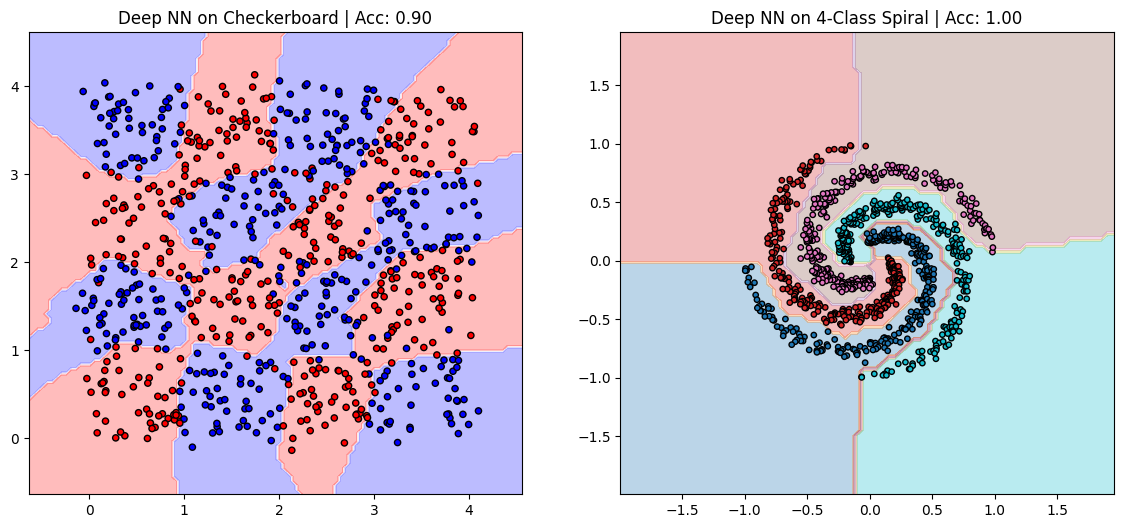

In [14]:
# 1. train nn on checkerboard (2 classes)
net_chk = NeuralNetworkScratch(hidden_layers=[64, 16], n_classes=2, learning_rate=0.2, epochs=40000, random_state=42)
net_chk.fit(X_checker, y_checker)

pred_chk = net_chk.predict(X_checker)
acc_chk_nn = np.mean(pred_chk == y_checker)

# 2. train nn on 4-class spiral
net_sp = NeuralNetworkScratch(hidden_layers=[16], n_classes=4, learning_rate=0.2, epochs=10000, random_state=42)
net_sp.fit(X_spiral4, y_spiral4)

pred_sp = net_sp.predict(X_spiral4)
acc_sp_nn = np.mean(pred_sp == y_spiral4)

# plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# plot checkerboard
x_min_c, x_max_c = X_checker[:, 0].min() - 0.5, X_checker[:, 0].max() + 0.5
y_min_c, y_max_c = X_checker[:, 1].min() - 0.5, X_checker[:, 1].max() + 0.5
xx_c, yy_c = np.meshgrid(np.arange(x_min_c, x_max_c, 0.05), np.arange(y_min_c, y_max_c, 0.05))
z_c = net_chk.predict(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)

ax[0].contourf(xx_c, yy_c, z_c, alpha=0.3, cmap="bwr")
ax[0].scatter(X_checker[:, 0], X_checker[:, 1], c=y_checker, cmap="bwr", edgecolors="k", s=20)
ax[0].set_title(f"Deep NN on Checkerboard | Acc: {acc_chk_nn:.2f}")

# plot spiral
x_min_s, x_max_s = X_spiral4[:, 0].min() - 1, X_spiral4[:, 0].max() + 1
y_min_s, y_max_s = X_spiral4[:, 1].min() - 1, X_spiral4[:, 1].max() + 1
xx_s, yy_s = np.meshgrid(np.arange(x_min_s, x_max_s, 0.05), np.arange(y_min_s, y_max_s, 0.05))
z_s = net_sp.predict(np.c_[xx_s.ravel(), yy_s.ravel()]).reshape(xx_s.shape)

ax[1].contourf(xx_s, yy_s, z_s, alpha=0.3, cmap="tab10")
ax[1].scatter(X_spiral4[:, 0], X_spiral4[:, 1], c=y_spiral4, cmap="tab10", edgecolors="k", s=15)
ax[1].set_title(f"Deep NN on 4-Class Spiral | Acc: {acc_sp_nn:.2f}")

plt.show()

### Training the Neural Network on MNIST

Now it is time to put our `NeuralNetwork` built entirely from scratch with `numpy` to the ultimate test! 

We will configure our network to accept **784 inputs** (our 28x28 flattened pixels) and output to **10 classes** (digits 0 through 9). For this task, a network with a single hidden layer of **128 neurons** is powerful enough to extract the necessary features from the handwriting.

*Note: Since our implementation uses Full-Batch Gradient Descent, calculating the gradients for all 60,000 images at once is mathematically heavy. Training might take 1-2 minutes. Grab a coffee and watch the loss drop!*

Initializing Neural Network...
Training started!
Epoch 1/15 done!
Epoch 2/15 done!
Epoch 3/15 done!
Epoch 4/15 done!
Epoch 5/15 done!
Epoch 6/15 done!
Epoch 7/15 done!
Epoch 8/15 done!
Epoch 9/15 done!
Epoch 10/15 done!
Epoch 11/15 done!
Epoch 12/15 done!
Epoch 13/15 done!
Epoch 14/15 done!
Epoch 15/15 done!

Training Complete!
Training Accuracy: 98.28%
Test Accuracy: 97.39%



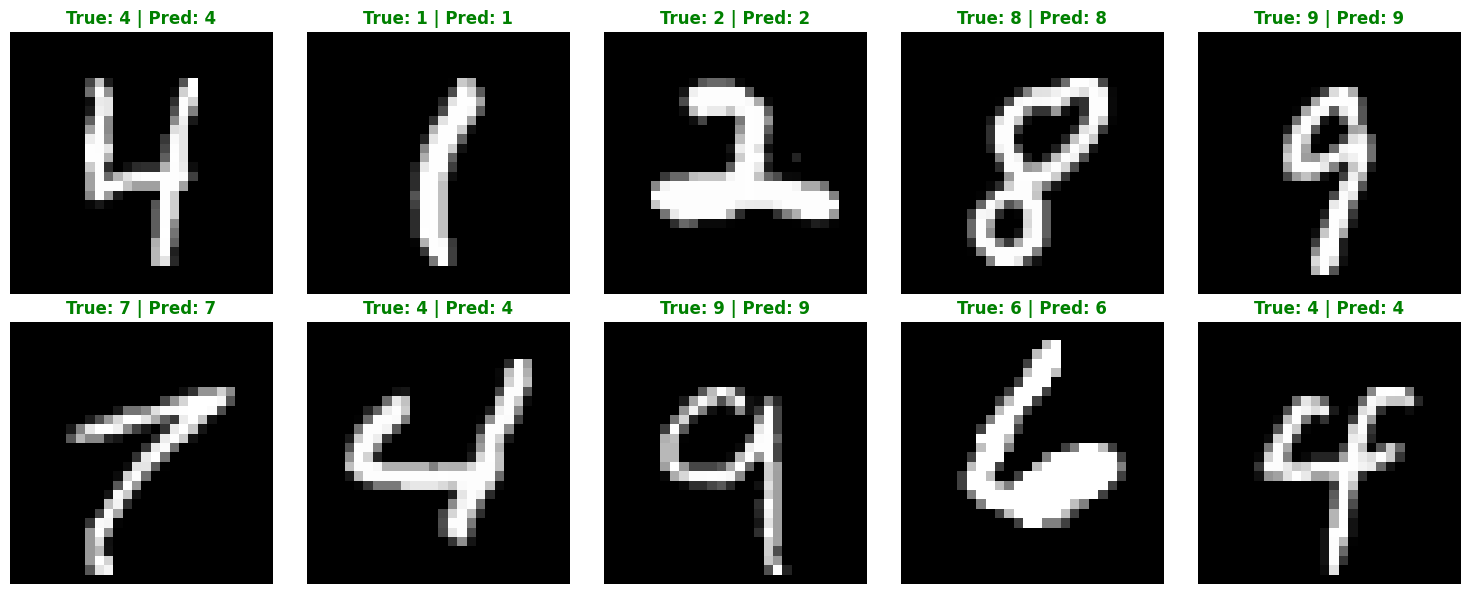

In [15]:
# Train the Neural Network on MNIST using Mini-Batch
print("Initializing Neural Network...")
# Notice the massive drop in epochs (15) and the addition of batch_size=128
net_mnist = NeuralNetworkScratch(
    hidden_layers=[128], 
    n_classes=10, 
    learning_rate=0.1, 
    epochs=15,       
    batch_size=128, 
    random_state=42
)

print("Training started!")
net_mnist.fit(X_train, y_train)

print("\nTraining Complete!")

# Calculate Accuracy on the Training set
train_preds = net_mnist.predict(X_train)
train_acc = np.mean(train_preds == y_train)
print(f"Training Accuracy: {train_acc * 100:.2f}%")


# Evaluate on Unseen Test Data
test_preds = net_mnist.predict(X_test)
test_acc = np.mean(test_preds == y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

# Visualize Predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X_test), 10, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = X_test[idx].reshape(28, 28)
    
    true_label = y_test[idx]
    pred_label = test_preds[idx]
    
    color = "green" if true_label == pred_label else "red"
    
    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color=color, fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.show()